## Setup

In [3]:
import numpy as np
from pathlib import Path
from itertools import product
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import t
import itertools

source = Path("..\\results\\20260225_162434")
data_type = ["compressible", "incompressible"]
mode = ["compress", "decompress"]
languages = ["cpp", "go", "java", "python"]

results = []

for dt, m, lang in product(data_type, mode, languages):
    path = source / dt / m / lang / "metrics.csv"
    df = pd.read_csv(path)
    results.append(df)

df = pd.concat(results, ignore_index=True)
df["j/s"] = df["total_energy_j"] / df["wall_time_s"]
df

,run,return_code,wall_time_s,compression_ratio,energy_per_mb_j,dataset,mode,lang,input,output,...,PACKAGE_ENERGY (J),PP0_ENERGY (J),PP1_ENERGY (J),TOTAL_MEMORY,TOTAL_SWAP,Time,USED_MEMORY,USED_SWAP,total_energy_j,j/s
0,1,0,3.596429,10.034113,0.056670,compressible,compress,cpp,results/20260225_162434/data/input_compressibl...,results/20260225_162434/compressible/compress/...,...,13.835571,7.076416,0.0,0.0,0.0,3105.0,7217152.0,0.0,13.835571,3.847030
1,2,0,3.581735,10.034113,0.057496,compressible,compress,cpp,results/20260225_162434/data/input_compressibl...,results/20260225_162434/compressible/compress/...,...,14.037048,7.094666,0.0,0.0,0.0,3105.0,-843776.0,0.0,14.037048,3.919064
2,3,0,3.599729,10.034113,0.056335,compressible,compress,cpp,results/20260225_162434/data/input_compressibl...,results/20260225_162434/compressible/compress/...,...,13.753662,7.008362,0.0,0.0,0.0,3105.0,1548288.0,0.0,13.753662,3.820749
3,4,0,3.615701,10.034113,0.056083,compressible,compress,cpp,results/20260225_162434/data/input_compressibl...,results/20260225_162434/compressible/compress/...,...,13.692139,6.903442,0.0,0.0,0.0,3104.0,-892928.0,0.0,13.692139,3.786856
4,5,0,3.710929,10.034113,0.057251,compressible,compress,cpp,results/20260225_162434/data/input_compressibl...,results/20260225_162434/compressible/compress/...,...,13.977417,7.100464,0.0,0.0,0.0,3206.0,-2822144.0,0.0,13.977417,3.766555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,26,0,1.624806,0.999839,0.019948,incompressible,decompress,python,results/20260225_162434/data/ref_incompressibl...,results/20260225_162434/incompressible/decompr...,...,4.870911,1.902344,0.0,0.0,0.0,1103.0,62427136.0,0.0,4.870911,2.997841
476,27,0,1.642457,0.999839,0.020843,incompressible,decompress,python,results/20260225_162434/data/ref_incompressibl...,results/20260225_162434/incompressible/decompr...,...,5.089417,2.009338,0.0,0.0,0.0,1102.0,89489408.0,0.0,5.089417,3.098660
477,28,0,1.617951,0.999839,0.019360,incompressible,decompress,python,results/20260225_162434/data/ref_incompressibl...,results/20260225_162434/incompressible/decompr...,...,4.727234,1.868225,0.0,0.0,0.0,1102.0,91176960.0,0.0,4.727234,2.921741
478,29,0,1.507420,0.999839,0.019568,incompressible,decompress,python,results/20260225_162434/data/ref_incompressibl...,results/20260225_162434/incompressible/decompr...,...,4.778076,2.079163,0.0,0.0,0.0,1002.0,65581056.0,0.0,4.778076,3.169705


## Raw Visualizations

In [4]:
# --- Violin plot ---
def raw_violin_plot(y, label):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    for ax, (dt, m) in zip(axes, product(data_type, mode)):
        subset = df[(df["dataset"] == dt) & (df["mode"] == m)]

        sns.violinplot(
            data=subset,
            x="lang",
            y=y,
            ax=ax
        )

        ax.set_title(f"{dt} - {m}")
        ax.set_xlabel("Language")
        ax.set_ylabel(label)

    plt.tight_layout()
    plt.show()

def select_data(ds, mode, lang):
    return df[(df["dataset"] == ds) & (df["mode"] == mode) & (df["lang"] == lang)]

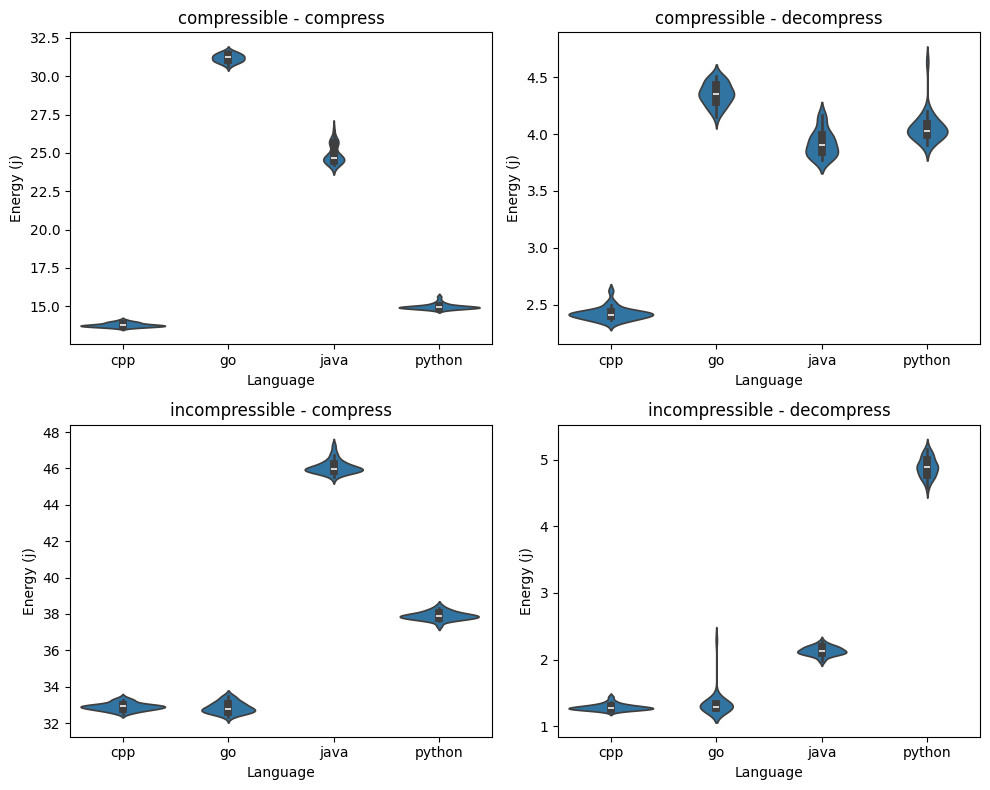

In [5]:
raw_violin_plot("total_energy_j", "Energy (j)")

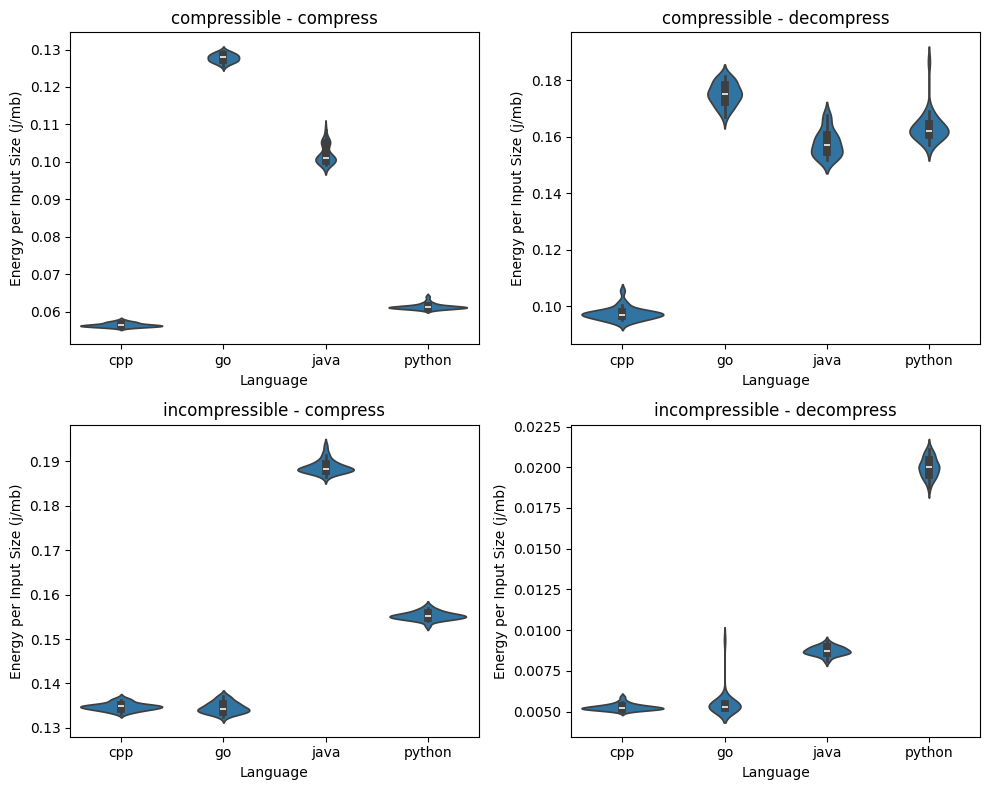

In [6]:
raw_violin_plot("energy_per_mb_j", "Energy per Input Size (j/mb)")

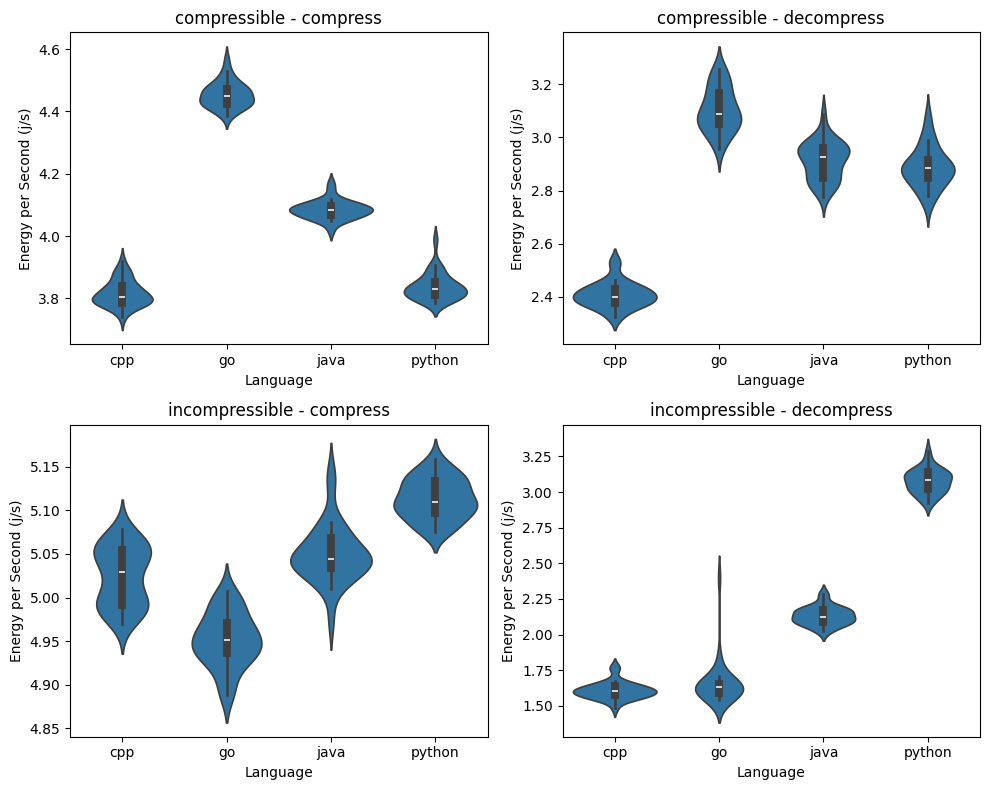

In [7]:
raw_violin_plot("j/s", "Energy per Second (j/s)")

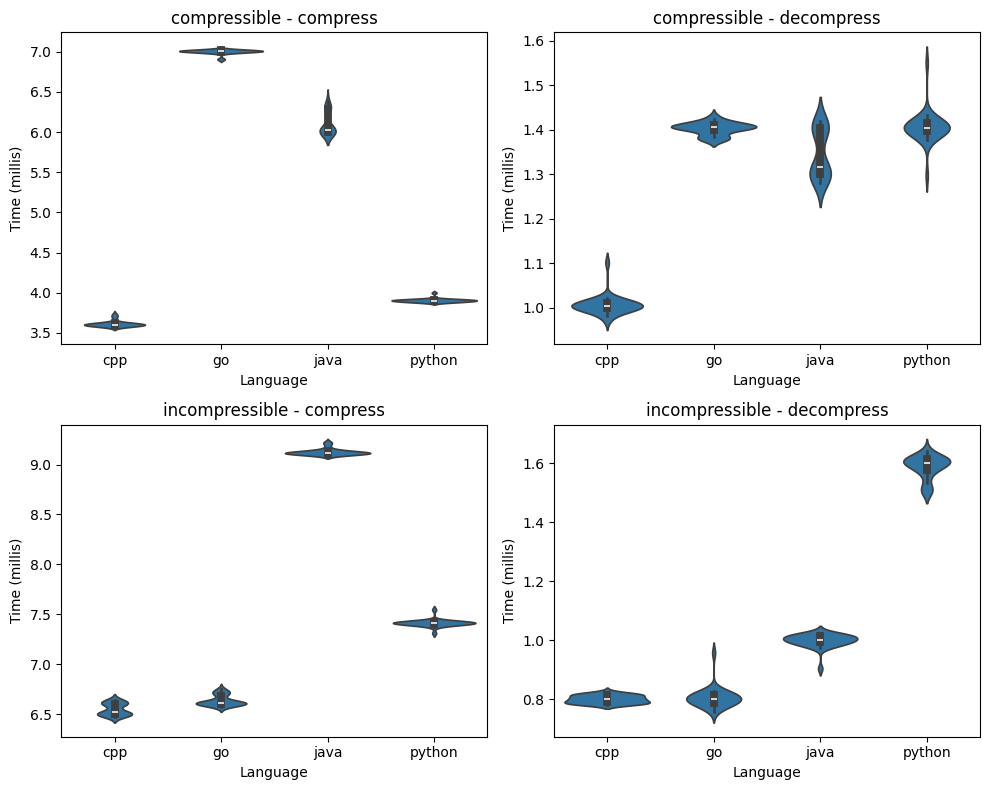

In [8]:
raw_violin_plot("wall_time_s", "Time (millis)")

## Compression Ratio

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import t

def compression_ratio_table(df):
    # keep only compression runs (CR is only meaningful there)
    comp = df[df["mode"] == "compress"].copy()

    CR_COL = "compression_ratio"
    if CR_COL not in comp.columns:
        raise KeyError(
            f"Expected column '{CR_COL}' in df. Available columns: {list(comp.columns)}"
        )

    g = comp.groupby(["dataset", "lang"])[CR_COL]
    out = g.agg(n="count", mean_CR="mean", std_CR=lambda x: x.std(ddof=1)).reset_index()

    # 95% t-based CI (same style as energy)
    tcrit = out["n"].apply(lambda n: t.ppf(0.975, df=n-1) if n > 1 else np.nan)
    se = out["std_CR"] / np.sqrt(out["n"])
    ci_half = tcrit * se
    out["ci_lower_CR"] = out["mean_CR"] - ci_half
    out["ci_upper_CR"] = out["mean_CR"] + ci_half

    # compact formatting for report
    out["mean_CI_CR"] = out.apply(
        lambda r: f'{r["mean_CR"]:.5f} [{r["ci_lower_CR"]:.5f}, {r["ci_upper_CR"]:.5f}]',
        axis=1
    )

    out = out.sort_values(["dataset", "lang"]).reset_index(drop=True)
    return out

cr_df = compression_ratio_table(df)

print("\n=== Compression ratio summary (long form) ===")
print(cr_df[["dataset","lang","n","mean_CR","std_CR","ci_lower_CR","ci_upper_CR"]].to_string(index=False))

print("\n=== Compression ratio summary (pivot: mean [CI]) ===")
cr_pivot = cr_df.pivot_table(index="dataset", columns="lang", values="mean_CI_CR", aggfunc="first")
print(cr_pivot.to_string())

# --- 1–2% consistency check per dataset ---
checks = []
for dataset, sub in cr_df.groupby("dataset"):
    best = sub["mean_CR"].min()  # lower CR is better (smaller compressed/original)
    sub = sub.copy()
    sub["pct_above_best"] = (sub["mean_CR"] - best) / best * 100.0
    max_gap = sub["pct_above_best"].max()
    checks.append({
        "dataset": dataset,
        "best_mean_CR": best,
        "max_pct_above_best": max_gap,
        "within_1pct": max_gap <= 1.0,
        "within_2pct": max_gap <= 2.0,
    })

check_df = pd.DataFrame(checks)

print("\n=== Are languages within 1–2% of each other (relative to best mean CR)? ===")
print(check_df.to_string(index=False))


=== Compression ratio summary (long form) ===
       dataset   lang  n   mean_CR       std_CR  ci_lower_CR  ci_upper_CR
  compressible    cpp 30 10.034113 1.806724e-15    10.034113    10.034113
  compressible     go 30 10.117324 0.000000e+00    10.117324    10.117324
  compressible   java 30  9.814242 1.806724e-15     9.814242     9.814242
  compressible python 30 10.034113 1.806724e-15    10.034113    10.034113
incompressible    cpp 30  0.999695 2.258405e-16     0.999695     0.999695
incompressible     go 30  0.999695 2.258405e-16     0.999695     0.999695
incompressible   java 30  0.999695 2.258405e-16     0.999695     0.999695
incompressible python 30  0.999695 2.258405e-16     0.999695     0.999695

=== Compression ratio summary (pivot: mean [CI]) ===
lang                                      cpp                             go                        java                         python
dataset                                                                                          

## Analysis

- RQ1: Do Python, Java, Go, and C++ differ significantly in energy consumption when performing identical gzip compression and decompression tasks under controlled conditions?
- RQ2: Are the observed energy differences consistent across data types (compressible vs. incompressible) and operations (compression vs. decompression), and how statistically significant are these differences?
- RQ3: Is the language that achieves the lowest runtime also the most energy efficient for gzip compression and decompression?

## Energy distribution per language (RQ1, RQ2)

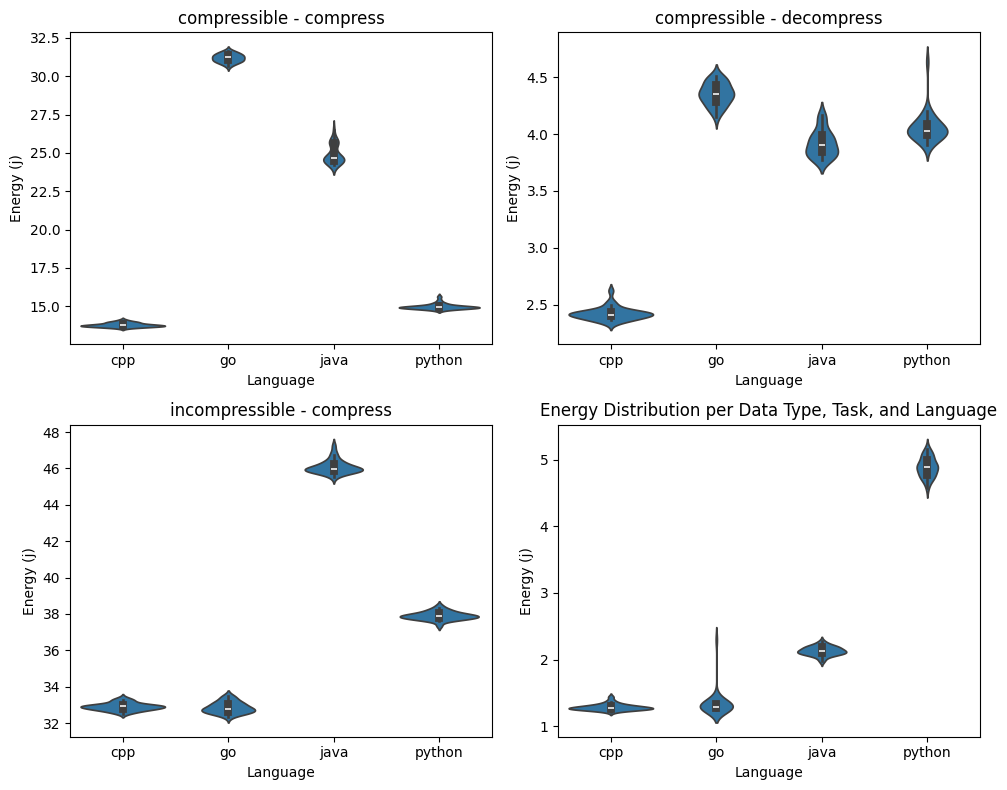

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (dt, m) in zip(axes, product(data_type, mode)):
    subset = df[(df["dataset"] == dt) & (df["mode"] == m)]

    sns.violinplot(
        data=subset,
        x="lang",
        y="total_energy_j",
        ax=ax
    )

    ax.set_title(f"{dt} - {m}")
    ax.set_xlabel("Language")
    ax.set_ylabel("Energy (j)")

plt.tight_layout()
plt.title("Energy Distribution per Data Type, Task, and Language")
plt.show()

## Energy against Time (RQ3)

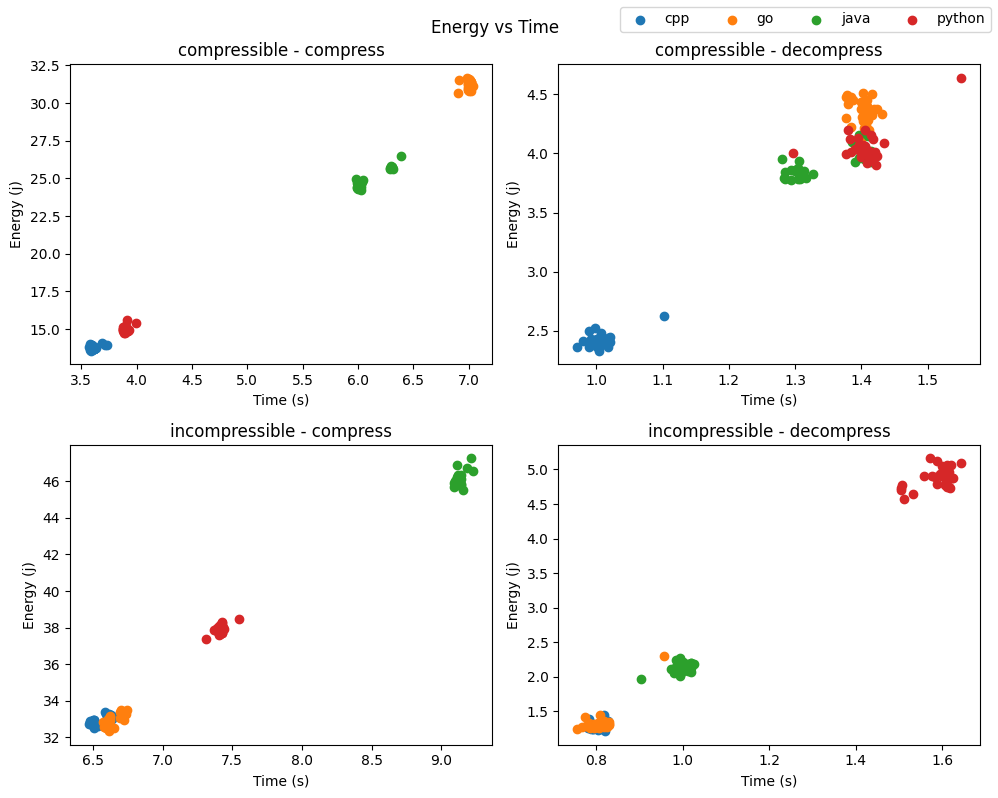

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

handles_dict = {}

for ax, (dt, m) in zip(axes, product(data_type, mode)):
    subset = df[(df["mode"] == m) & (df["dataset"] == dt)]

    for lang, group in subset.groupby("lang"):
        sc = ax.scatter(
            group["wall_time_s"],
            group["total_energy_j"],
            label=lang
        )
        # store only first handle per language
        if lang not in handles_dict:
            handles_dict[lang] = sc

    ax.set_title(f"{dt} - {m}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Energy (j)")

plt.tight_layout(rect=[0, 0, 1, 0.97])

fig.legend(
    handles_dict.values(),
    handles_dict.keys(),
    loc="upper right",
    ncol=len(handles_dict)
)

plt.suptitle("Energy vs Time")

plt.show()

## Mean Energy Usage (RQ1, RQ2)

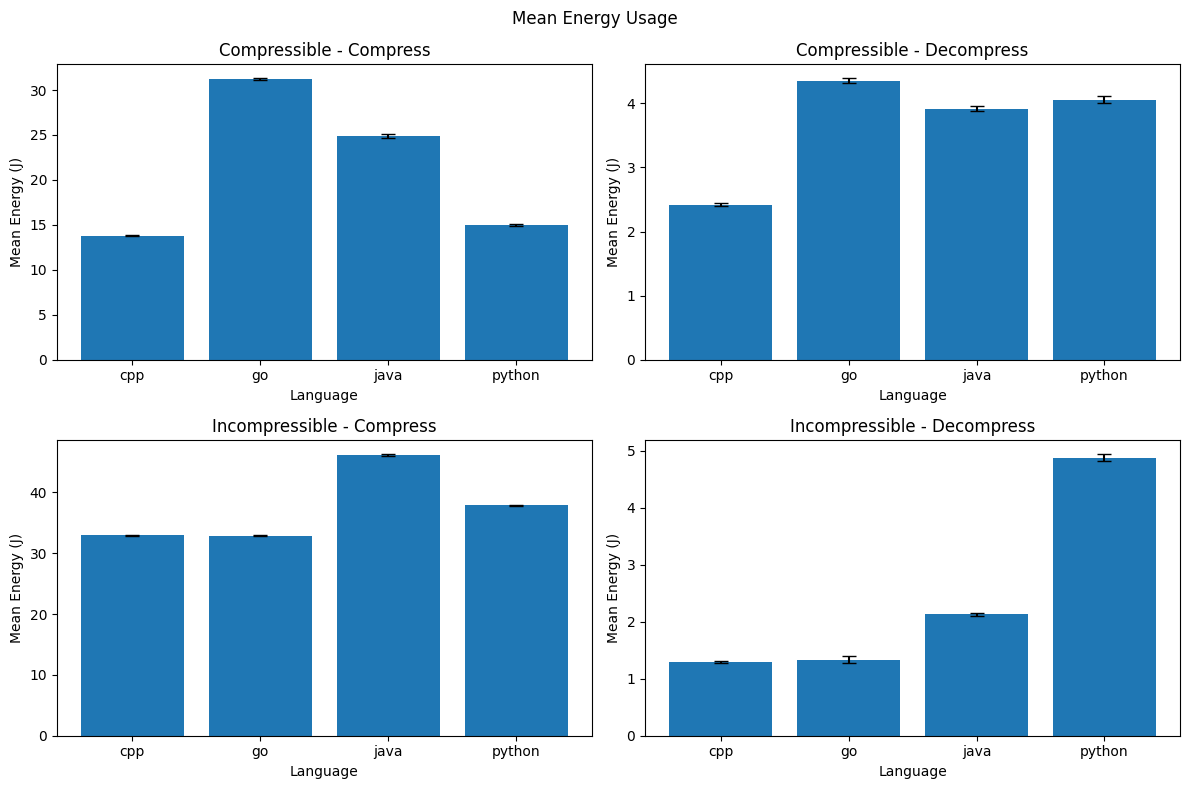

In [11]:
def show_mean_w_confidence(ax, m, ds, title):
    subset = df[(df["mode"] == m) & (df["dataset"] == ds)]
    grouped = subset.groupby("lang")["total_energy_j"]

    means = grouped.mean()
    std = grouped.std(ddof=1)
    n = grouped.count()

    # 95% CI using t-distribution
    ci = t.ppf(0.975, n-1) * (std / np.sqrt(n))

    ax.bar(means.index, means.values, yerr=ci.values, capsize=5)
    ax.set_ylabel("Mean Energy (J)")
    ax.set_xlabel("Language")
    ax.set_title(title)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

show_mean_w_confidence(axes[0, 0], mode[0], data_type[0], "Compressible - Compress")
show_mean_w_confidence(axes[0, 1], mode[1], data_type[0], "Compressible - Decompress")

show_mean_w_confidence(axes[1, 0], mode[0], data_type[1], "Incompressible - Compress")
show_mean_w_confidence(axes[1, 1], mode[1], data_type[1], "Incompressible - Decompress")

fig.suptitle("Mean Energy Usage")
plt.tight_layout()
plt.show()
# 3: Mean energy with confidence intervals

## Effect sizes (RQ2)

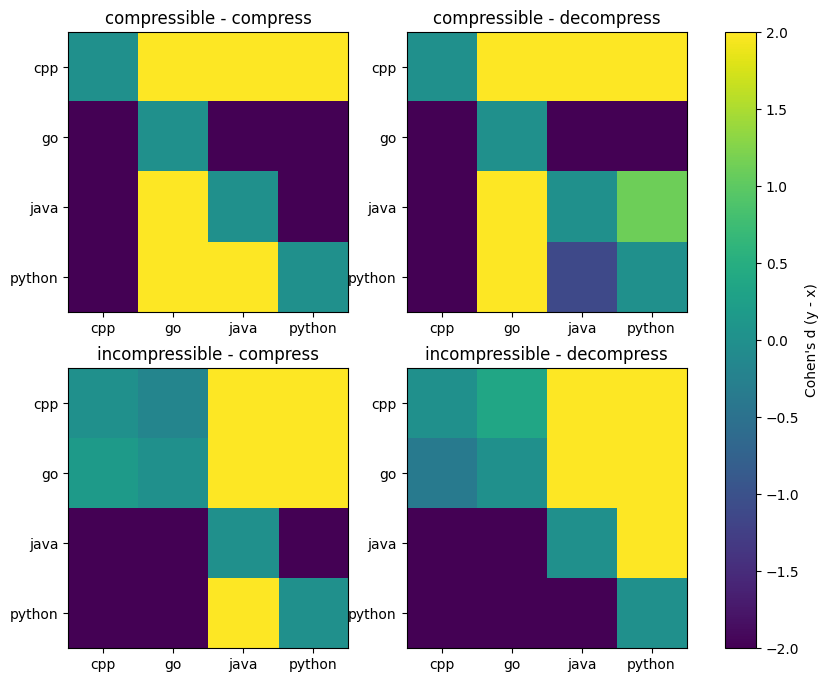

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

def cohens_d(x, y):
    sx, sy = np.std(x, ddof=1), np.std(y, ddof=1)
    s_pooled = np.sqrt((sx**2 + sy**2) / 2)
    return (np.mean(y) - np.mean(x)) / s_pooled

languages = sorted(df["lang"].unique())
datasets = sorted(df["dataset"].unique())
modes = sorted(df["mode"].unique())

fig, axes = plt.subplots(len(datasets), len(modes),
                         figsize=(5 * len(modes), 4 * len(datasets)))

# Ensure 2D indexing
if len(datasets) == 1:
    axes = np.array([axes])
if len(modes) == 1:
    axes = axes.reshape(-1, 1)

for i, ds in enumerate(datasets):
    for j, m in enumerate(modes):
        ax = axes[i, j]
        subset = df[(df["dataset"] == ds) & (df["mode"] == m)]

        mat = np.zeros((len(languages), len(languages)))

        for a, lang_a in enumerate(languages):
            for b, lang_b in enumerate(languages):
                if a == b:
                    mat[a, b] = 0
                else:
                    x = subset[subset["lang"] == lang_a]["total_energy_j"]
                    y = subset[subset["lang"] == lang_b]["total_energy_j"]

                    if len(x) > 1 and len(y) > 1:
                        mat[a, b] = cohens_d(x, y)
                    else:
                        mat[a, b] = np.nan

        im = ax.imshow(mat, vmin=-2, vmax=2)
        ax.set_xticks(range(len(languages)))
        ax.set_yticks(range(len(languages)))
        ax.set_xticklabels(languages)
        ax.set_yticklabels(languages)
        ax.set_title(f"{ds} - {m}")

fig.colorbar(im, ax=axes.ravel().tolist(), label="Cohen's d (y - x)")
plt.show()

## Energy per MB (RQ1, RQ2)

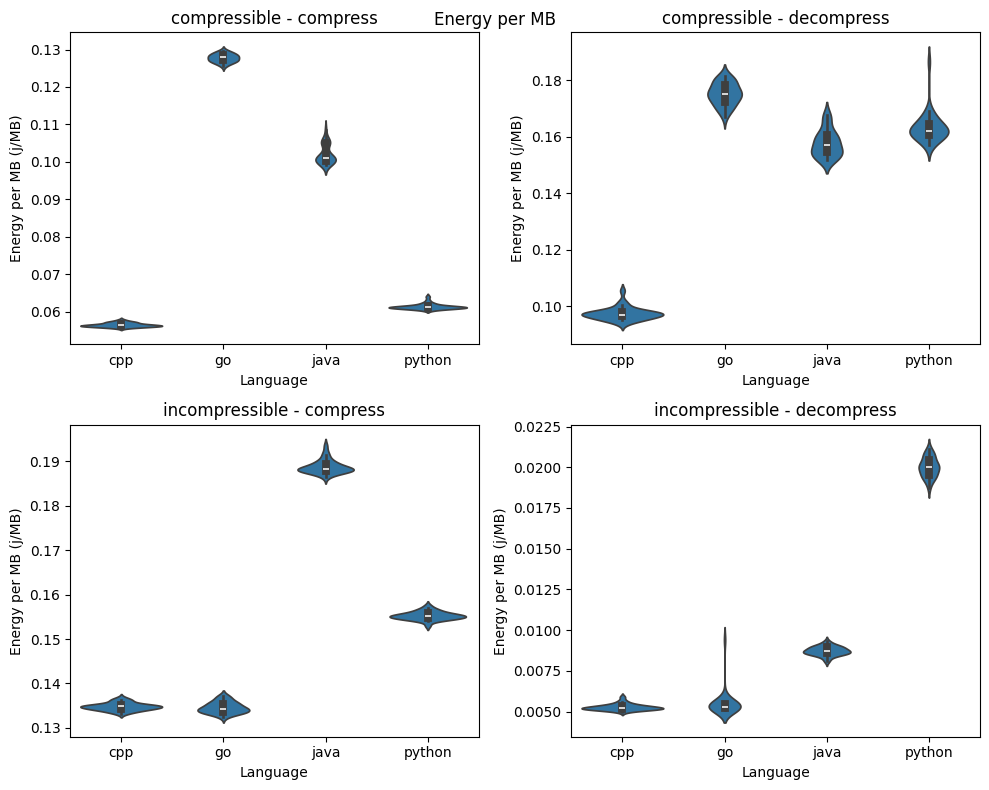

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (dt, m) in zip(axes, product(data_type, mode)):
    subset = df[(df["dataset"] == dt) & (df["mode"] == m)]

    sns.violinplot(
        data=subset,
        x="lang",
        y="energy_per_mb_j",
        ax=ax
    )

    ax.set_title(f"{dt} - {m}")
    ax.set_xlabel("Language")
    ax.set_ylabel("Energy per MB (j/MB)")

plt.tight_layout()
fig.suptitle("Energy per MB")
plt.show()

## Statistical Analysis (RQ1, RQ2)

In [14]:
results = []
for ds, m, lang in product(data_type, mode, languages):
    subset = df[
        (df["dataset"] == ds) &
        (df["mode"] == m) &
        (df["lang"] == lang)
    ]["total_energy_j"]

    n = len(subset)
    mean = subset.mean()
    std = subset.std(ddof=1)

    t_crit = t.ppf(0.975, df=n-1)
    ci_half = t_crit * std / np.sqrt(n)

    results.append({
        "dataset": ds,
        "mode": m,
        "lang": lang,
        "mean_J": mean,
        "std_J": std,
        "ci_lower_J": mean - ci_half,
        "ci_upper_J": mean + ci_half
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["dataset", "mode", "lang"])

results_df

,dataset,mode,lang,mean_J,std_J,ci_lower_J,ci_upper_J
0,compressible,compress,cpp,13.787813,0.130937,13.738921,13.836706
1,compressible,compress,go,31.190413,0.267951,31.090359,31.290468
2,compressible,compress,java,24.927991,0.611432,24.699678,25.156303
3,compressible,compress,python,14.984863,0.177658,14.918525,15.051202
4,compressible,decompress,cpp,2.421851,0.056189,2.400869,2.442832
5,compressible,decompress,go,4.353898,0.097424,4.317519,4.390277
6,compressible,decompress,java,3.919346,0.116540,3.875829,3.962863
7,compressible,decompress,python,4.058803,0.131873,4.009561,4.108045
8,incompressible,compress,cpp,32.909344,0.205607,32.832570,32.986119
9,incompressible,compress,go,32.861523,0.303943,32.748029,32.975018


In [15]:
from scipy.stats import t

def energy_summary_table(df):
    # group by condition + language
    g = df.groupby(["dataset", "mode", "lang"])["total_energy_j"]

    out = g.agg(n="count", mean_J="mean", std_J=lambda x: x.std(ddof=1)).reset_index()

    # 95% t-based CI
    tcrit = out["n"].apply(lambda n: t.ppf(0.975, df=n-1) if n > 1 else np.nan)
    se = out["std_J"] / np.sqrt(out["n"])
    ci_half = tcrit * se

    out["ci_lower_J"] = out["mean_J"] - ci_half
    out["ci_upper_J"] = out["mean_J"] + ci_half

    # optional: nice formatting column for the report
    out["mean_CI_J"] = out.apply(
        lambda r: f'{r["mean_J"]:.2f} [{r["ci_lower_J"]:.2f}, {r["ci_upper_J"]:.2f}]',
        axis=1
    )

    # sort for readability
    out = out.sort_values(["dataset", "mode", "lang"]).reset_index(drop=True)
    return out

summary_df = energy_summary_table(df)

# 1) full long-form table (good for appendix / export)
print("\n=== Energy summary (long form) ===")
print(summary_df[["dataset","mode","lang","n","mean_J","std_J","ci_lower_J","ci_upper_J"]].to_string(index=False))

# 2) per-condition pivot table for the report (compact)
print("\n=== Energy summary (pivot: mean [CI]) ===")
pivot = summary_df.pivot_table(
    index=["dataset","mode"],
    columns="lang",
    values="mean_CI_J",
    aggfunc="first"
)
print(pivot.to_string())

# 3) optional: save to CSV for LaTeX/Word copy-paste
summary_df.to_csv(source / "energy_summary_table.csv", index=False)
pivot.to_csv(source / "energy_summary_pivot.csv")


=== Energy summary (long form) ===
       dataset       mode   lang  n    mean_J    std_J  ci_lower_J  ci_upper_J
  compressible   compress    cpp 30 13.787813 0.130937   13.738921   13.836706
  compressible   compress     go 30 31.190413 0.267951   31.090359   31.290468
  compressible   compress   java 30 24.927991 0.611432   24.699678   25.156303
  compressible   compress python 30 14.984863 0.177658   14.918525   15.051202
  compressible decompress    cpp 30  2.421851 0.056189    2.400869    2.442832
  compressible decompress     go 30  4.353898 0.097424    4.317519    4.390277
  compressible decompress   java 30  3.919346 0.116540    3.875829    3.962863
  compressible decompress python 30  4.058803 0.131873    4.009561    4.108045
incompressible   compress    cpp 30 32.909344 0.205607   32.832570   32.986119
incompressible   compress     go 30 32.861523 0.303943   32.748029   32.975018
incompressible   compress   java 30 46.094031 0.365908   45.957399   46.230663
incompressible  

## Percent Change (RQ1)

In [16]:
results = []

for (ds, mode), group in df.groupby(["dataset", "mode"]):
    means = group.groupby("lang")["total_energy_j"].mean()

    for a, b in itertools.combinations(means.index, 2):
        mean_a = means[a]
        mean_b = means[b]

        pct_change = ((mean_b - mean_a) / mean_a) * 100

        results.append({
            "dataset": ds,
            "mode": mode,
            "baseline_lang": a,
            "compare_lang": b,
            "percent_change": pct_change
        })

pd.DataFrame(results)

,dataset,mode,baseline_lang,compare_lang,percent_change
0,compressible,compress,cpp,go,126.217259
1,compressible,compress,cpp,java,80.797275
2,compressible,compress,cpp,python,8.681942
3,compressible,compress,go,java,-20.078037
4,compressible,compress,go,python,-51.956830
5,compressible,compress,java,python,-39.887400
6,compressible,decompress,cpp,go,79.775670
7,compressible,decompress,cpp,java,61.832697
8,compressible,decompress,cpp,python,67.590987
9,compressible,decompress,go,java,-9.980757


## All Effect Size Analysis

In [26]:
import numpy as np
import pandas as pd
import itertools

def cohens_d(x, y):
    # Same definition you used in the heatmap cell
    sx, sy = np.std(x, ddof=1), np.std(y, ddof=1)
    s_pooled = np.sqrt((sx**2 + sy**2) / 2)
    return (np.mean(y) - np.mean(x)) / s_pooled

rows = []
langs = sorted(df["lang"].unique())

for (ds, m), sub in df.groupby(["dataset", "mode"]):
    for lang_a, lang_b in itertools.combinations(langs, 2):
        x = sub[sub["lang"] == lang_a]["total_energy_j"].dropna().to_numpy()
        y = sub[sub["lang"] == lang_b]["total_energy_j"].dropna().to_numpy()

        if len(x) < 2 or len(y) < 2:
            continue

        mean_a = x.mean()
        mean_b = y.mean()

        mean_diff_J = mean_b - mean_a
        pct_change = (mean_diff_J / mean_a) * 100.0
        d = cohens_d(x, y)

        rows.append({
            "dataset": ds,
            "mode": m,
            "lang_a": lang_a,
            "lang_b": lang_b,
            "cohens_d_(b-a)": d,
            "mean_diff_J_(b-a)": mean_diff_J,
            "pct_change_%_(b_vs_a)": pct_change,
            "mean_a_J": mean_a,
            "mean_b_J": mean_b,
        })

effect_table = pd.DataFrame(rows).sort_values(
    ["dataset", "mode", "lang_a", "lang_b"]
).reset_index(drop=True)

print(effect_table.to_string(index=False))

       dataset       mode lang_a lang_b  cohens_d_(b-a)  mean_diff_J_(b-a)  pct_change_%_(b_vs_a)  mean_a_J  mean_b_J
  compressible   compress    cpp     go       82.522902          17.402600             126.217259 13.787813 31.190413
  compressible   compress    cpp   java       25.195445          11.140177              80.797275 13.787813 24.927991
  compressible   compress    cpp python        7.670637           1.197050               8.681942 13.787813 14.984863
  compressible   compress     go   java      -13.266662          -6.262423             -20.078037 31.190413 24.927991
  compressible   compress     go python      -71.285573         -16.205550             -51.956830 31.190413 14.984863
  compressible   compress   java python      -22.084609          -9.943127             -39.887400 24.927991 14.984863
  compressible decompress    cpp     go       24.294733           1.932048              79.775670  2.421851  4.353898
  compressible decompress    cpp   java       16.368866 

## Pearson correlation between runtime and energy (RQ3)

In [28]:
from scipy.stats import pearsonr
import numpy as np
import pandas as pd

rows = []
for (ds, mode, lang), g in df.groupby(["dataset", "mode", "lang"]):
    x = g["wall_time_s"].to_numpy()
    y = g["total_energy_j"].to_numpy()
    if len(g) >= 3 and np.std(x) > 0 and np.std(y) > 0:
        r, p = pearsonr(x, y)
    else:
        r, p = np.nan, np.nan
    rows.append({"dataset": ds, "mode": mode, "lang": lang, "pearson_r": r, "p_value": p})

within_lang_corr = pd.DataFrame(rows).sort_values(["dataset","mode","lang"])
within_lang_corr

,dataset,mode,lang,pearson_r,p_value
0,compressible,compress,cpp,0.399413,2.876873e-02
1,compressible,compress,go,0.062862,7.413972e-01
2,compressible,compress,java,0.953849,3.668814e-16
3,compressible,compress,python,0.340826,6.531711e-02
4,compressible,decompress,cpp,0.597049,4.957424e-04
5,compressible,decompress,go,-0.234435,2.124132e-01
6,compressible,decompress,java,0.779239,3.908980e-07
7,compressible,decompress,python,0.609013,3.548397e-04
8,incompressible,compress,cpp,0.670828,4.972472e-05
9,incompressible,compress,go,0.744252,2.419168e-06


## Shapiro-Wilk (RQ2)

In [18]:
from scipy.stats import shapiro

results = []

for (ds, m), group in df.groupby(["dataset", "mode"]):
    for lang, g in group.groupby("lang"):
        values = g["total_energy_j"].dropna()

        if len(values) >= 3:  # Shapiro requires at least 3
            W, p = shapiro(values)

            results.append({
                "dataset": ds,
                "mode": m,
                "lang": lang,
                "W": W,
                "p_value": p,
                "normal_0.05": p > 0.05
            })

pd.DataFrame(results)

,dataset,mode,lang,W,p_value,normal_0.05
0,compressible,compress,cpp,0.941976,1.028241e-01,True
1,compressible,compress,go,0.980313,8.338067e-01,True
2,compressible,compress,java,0.840987,4.038257e-04,False
3,compressible,compress,python,0.785829,3.655971e-05,False
4,compressible,decompress,cpp,0.861749,1.103541e-03,False
5,compressible,decompress,go,0.976164,7.170051e-01,True
6,compressible,decompress,java,0.913648,1.841219e-02,False
7,compressible,decompress,python,0.715353,2.630398e-06,False
8,incompressible,compress,cpp,0.973907,6.505627e-01,True
9,incompressible,compress,go,0.955466,2.362211e-01,True


## Welch's t-test between languages per mode/data type (RQ2)

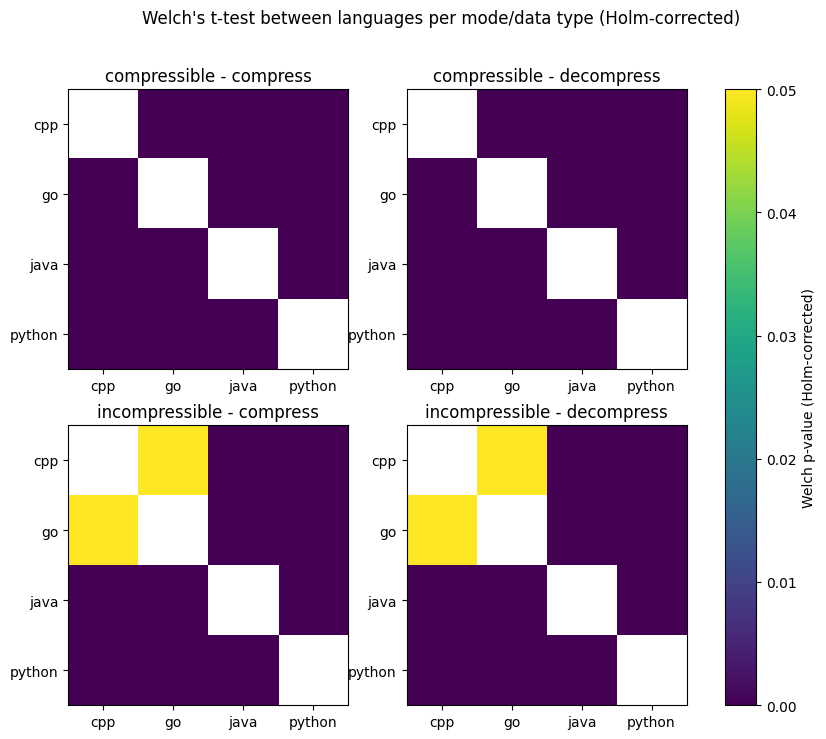

       dataset       mode lang_a lang_b       p_holm  reject_0.05
  compressible   compress     go python 5.453859e-81         True
  compressible   compress    cpp     go 3.351370e-72         True
  compressible   compress   java python 1.501396e-40         True
  compressible   compress    cpp   java 2.392463e-40         True
  compressible   compress     go   java 1.153604e-37         True
  compressible   compress    cpp python 7.440119e-35         True
  compressible decompress    cpp     go 8.131420e-54         True
  compressible decompress    cpp   java 1.815364e-42         True
  compressible decompress    cpp python 2.776046e-40         True
  compressible decompress     go   java 1.070143e-21         True
  compressible decompress     go python 2.556869e-13         True
  compressible decompress   java python 5.874142e-05         True
incompressible   compress     go   java 2.291642e-74         True
incompressible   compress    cpp   java 3.703993e-65         True
incompress

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

languages = sorted(df["lang"].unique())
datasets = sorted(df["dataset"].unique())
modes = sorted(df["mode"].unique())

pairwise_rows = []

fig, axes = plt.subplots(len(datasets), len(modes),
                         figsize=(5 * len(modes), 4 * len(datasets)))

if len(datasets) == 1:
    axes = np.array([axes])
if len(modes) == 1:
    axes = axes.reshape(-1, 1)

for i, ds in enumerate(datasets):
    for j, m in enumerate(modes):
        ax = axes[i, j]
        subset = df[(df["dataset"] == ds) & (df["mode"] == m)]

        p_mat = np.full((len(languages), len(languages)), np.nan)

        pvals = []
        pairs = []
        raw_map = {}

        # --- collect raw p-values ---
        for a in range(len(languages)):
            for b in range(a + 1, len(languages)):
                lang_a = languages[a]
                lang_b = languages[b]

                x = subset[subset["lang"] == lang_a]["total_energy_j"].dropna()
                y = subset[subset["lang"] == lang_b]["total_energy_j"].dropna()

                if len(x) > 1 and len(y) > 1:
                    _, p_raw = ttest_ind(x, y, equal_var=False)
                    pvals.append(p_raw)
                    pairs.append((a, b))
                    raw_map[(a, b)] = p_raw

        # --- Holm correction + fill matrix + store exact p-values ---
        if pvals:
            reject, pvals_corr, _, _ = multipletests(
                pvals,
                alpha=0.05,
                method="holm"
            )

            for (a, b), p_corr, rej in zip(pairs, pvals_corr, reject):
                # fill symmetric matrix for heatmap
                p_mat[a, b] = p_corr
                p_mat[b, a] = p_corr

                pairwise_rows.append({
                    "dataset": ds,
                    "mode": m,
                    "lang_a": languages[a],
                    "lang_b": languages[b],
                    "p_holm": p_corr,
                    "reject_0.05": bool(rej),
                })

        im = ax.imshow(p_mat, vmin=0, vmax=0.05)
        ax.set_xticks(range(len(languages)))
        ax.set_yticks(range(len(languages)))
        ax.set_xticklabels(languages)
        ax.set_yticklabels(languages)
        ax.set_title(f"{ds} - {m}")

fig.colorbar(im, ax=axes.ravel().tolist(), label="Welch p-value (Holm-corrected)")
fig.suptitle("Welch's t-test between languages per mode/data type (Holm-corrected)")
plt.show()

welch_table = pd.DataFrame(pairwise_rows).sort_values(["dataset","mode","p_holm","lang_a","lang_b"])
print(welch_table.to_string(index=False))